In [1]:
# Import libraries
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [2]:
# Download the data files
!rm *.csv
!wget -q https://www.cs.utexas.edu/~kiat/datasets/Revised_Final_Data/Station1_Revised_Final_Data.csv
!wget -q https://www.cs.utexas.edu/~kiat/datasets/Revised_Final_Data/Station2_Revised_Final_Data.csv
!wget -q https://www.cs.utexas.edu/~kiat/datasets/Revised_Final_Data/Station3_Revised_Final_Data.csv
!wget -q https://www.cs.utexas.edu/~kiat/datasets/Revised_Final_Data/Station4_Revised_Final_Data.csv
!wget -q https://www.cs.utexas.edu/~kiat/datasets/Revised_Final_Data/Station5_Revised_Final_Data.csv
!wget -q https://www.cs.utexas.edu/~kiat/datasets/Revised_Final_Data/Station6_Revised_Final_Data.csv

In [3]:
# List of stations
stations = {
    'Station1_Revised_Final_Data.csv': 'Station 1',
    'Station2_Revised_Final_Data.csv': 'Station 2',
    'Station3_Revised_Final_Data.csv': 'Station 3',
    'Station4_Revised_Final_Data.csv': 'Station 4',
    'Station5_Revised_Final_Data.csv': 'Station 5',
    'Station6_Revised_Final_Data.csv': 'Station 6'
}

In [4]:
# Load and process data for each station
def load_rainfall_data(file, station_name, time = 'year', pivot = False):
    df = pd.read_csv(file, index_col=0, parse_dates=True)
    df.reset_index(inplace=True)
    df.rename(columns={'index': 'Date'}, inplace=True)
    
    if time == 'year':
        df['Group'] = df['Date'].dt.year
    elif time == 'month':
        df['Group'] = df['Date'].dt.to_period('M').astype(str)
    elif time == 'month_matrix':
        df['Year'] = df['Date'].dt.year
        df['Month'] = df['Date'].dt.month_name()
        df['Month_num'] = df['Date'].dt.month
        monthly_totals = df.groupby(['Year', 'Month', 'Month_num'])['Ppt'].sum().reset_index()
        matrix = monthly_totals.pivot_table(index='Month', columns='Year', values='Ppt')
        ordered_months = ['January', 'February', 'March', 'April', 'May', 'June',
                          'July', 'August', 'September', 'October', 'November', 'December']
        return matrix.reindex(ordered_months)
    else:
        raise ValueError("`by` must be 'year', 'month', or 'month_matrix'")

    totals = df.groupby('Group')['Ppt'].sum().reset_index()
    totals.columns = [time.title(), station_name]

    if pivot:
        return totals.set_index(time.title())
    return totals

In [5]:
# Merge all data into rainfall per year
rain_year_df = None
for file, name in stations.items():
    df = load_rainfall_data(file, name, time = 'year')
    rain_year_df = df if rain_year_df is None else pd.merge(rain_year_df, df, on = 'Year', how = 'outer')
rain_year_df.set_index('Year', inplace=True)

In [6]:
rain_year_df.head()

,Station 1,Station 2,Station 3,Station 4,Station 5,Station 6
Year,,,,,,
2015,488.400000,800.38,942.71,755.58,810.71,731.69
2016,476.870000,864.62,890.41,926.76,814.81,638.30
2017,604.050000,528.76,649.38,629.81,620.43,441.23
2018,891.553044,692.70,740.80,659.74,654.00,798.36
2019,480.710000,501.91,558.57,485.00,441.59,458.35


In [7]:
# Merge all data into rainfall per month
rain_month_df = None
for file, name in stations.items():
    df = load_rainfall_data(file, name, time = 'month')
    rain_month_df = df if rain_month_df is None else pd.merge(rain_month_df, df, on = 'Month', how = 'outer')
rain_month_df.set_index('Month', inplace=True)

In [8]:
rain_month_df.head(10)

,Station 1,Station 2,Station 3,Station 4,Station 5,Station 6
Month,,,,,,
2015-01,53.48,76.89,75.15,56.00,71.56,42.87
2015-02,4.29,5.05,5.33,4.79,3.30,3.04
2015-03,57.82,48.13,53.26,60.07,61.65,49.46
2015-04,58.92,64.74,74.66,65.52,99.30,55.11
2015-05,219.44,245.06,264.86,208.24,230.35,243.82
2015-06,56.63,50.79,89.64,73.63,26.89,41.14
2015-07,28.19,2.03,17.27,0.00,0.00,5.58
2015-08,1.01,4.06,15.74,20.32,10.16,18.79
2015-09,8.62,16.00,14.48,5.82,10.41,6.60


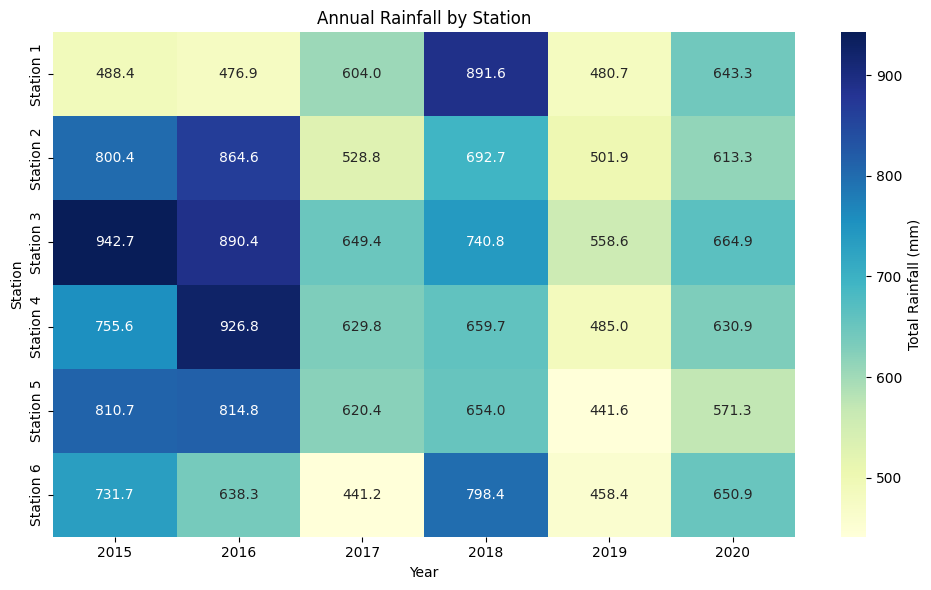

In [9]:
# Plot the heatmap by year
plt.figure(figsize=(10, 6))
sns.heatmap(rain_year_df.T, cmap = "YlGnBu", annot = True, fmt = ".1f", cbar_kws = {'label': 'Total Rainfall (mm)'})
plt.title("Annual Rainfall by Station")
plt.xlabel("Year")
plt.ylabel("Station")
plt.tight_layout()
plt.show()

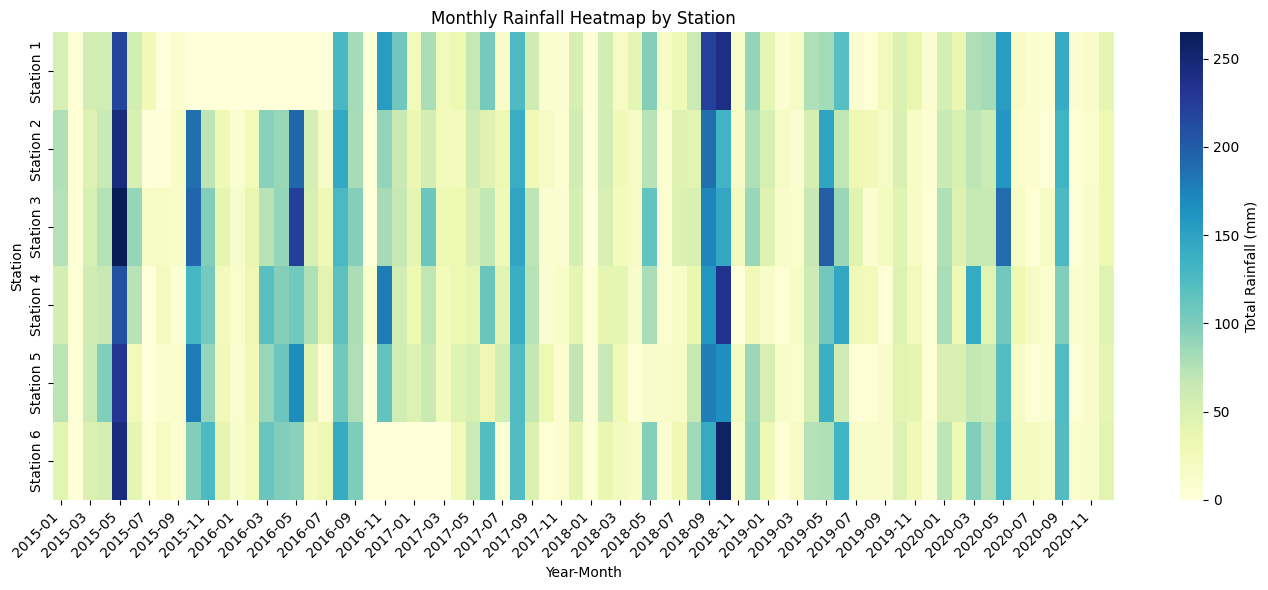

In [10]:
# Plot the heatmap by month
plt.figure(figsize = (14, 6))
sns.heatmap(rain_month_df.T, cmap = "YlGnBu", cbar_kws = {'label': 'Total Rainfall (mm)'})
plt.title("Monthly Rainfall Heatmap by Station")
plt.xlabel("Year-Month")
plt.ylabel("Station")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

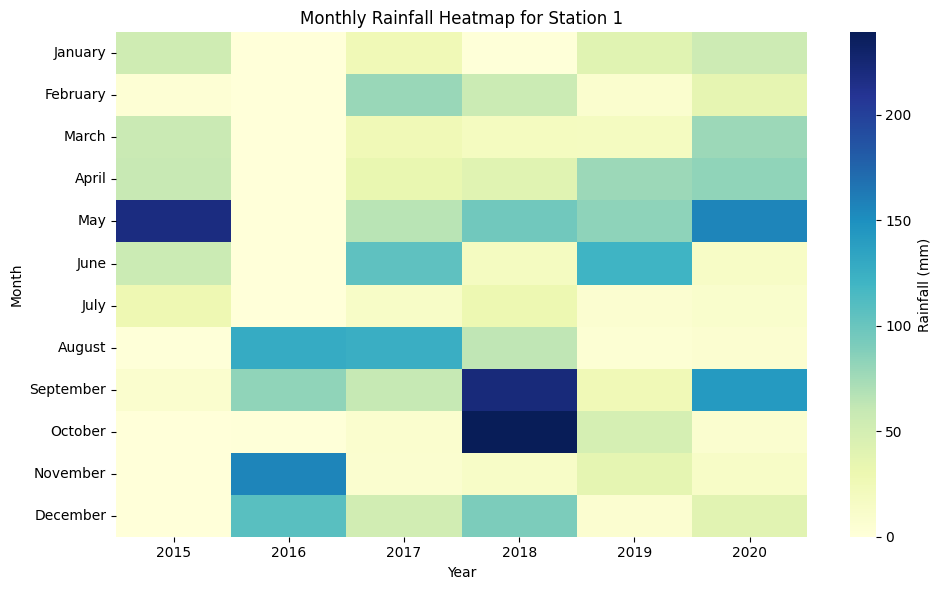

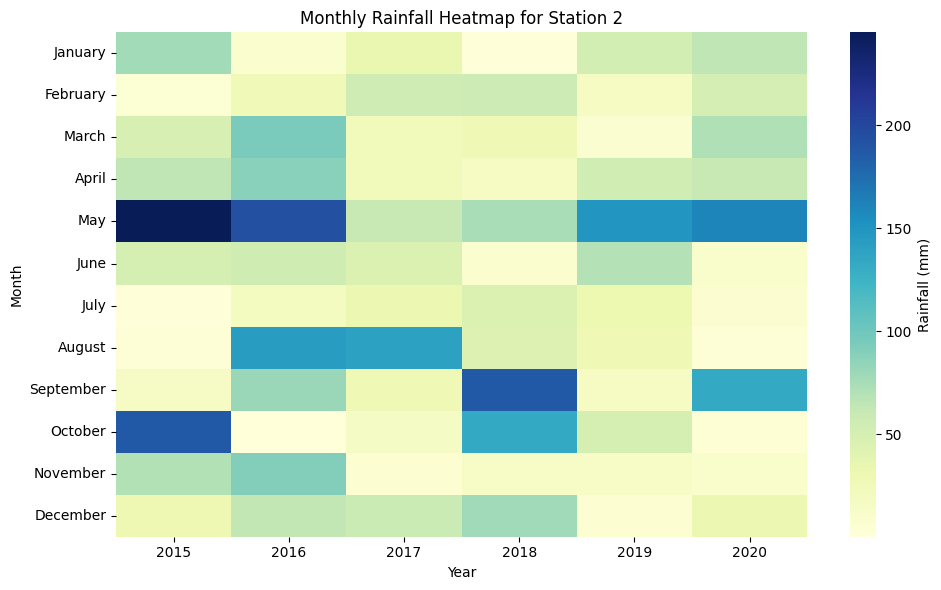

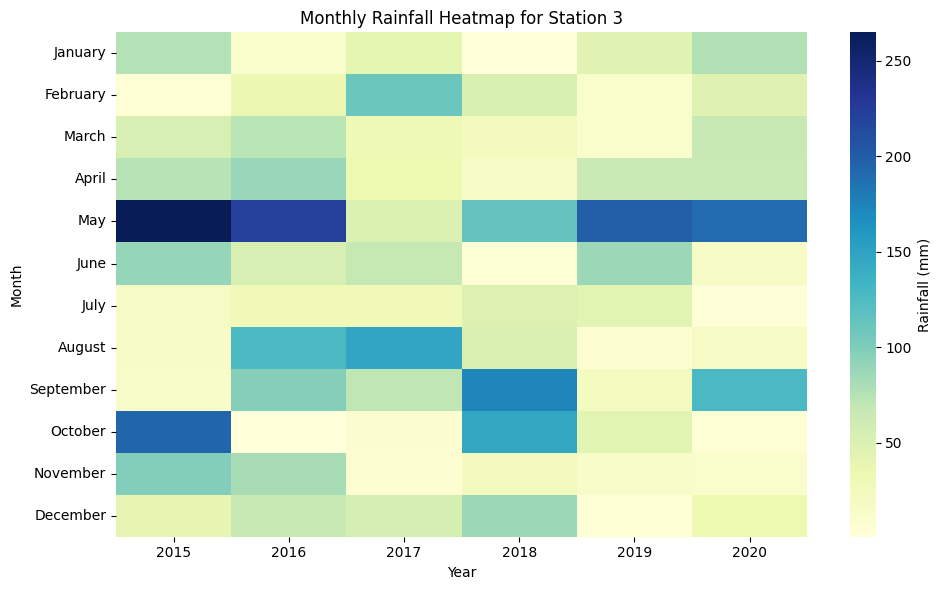

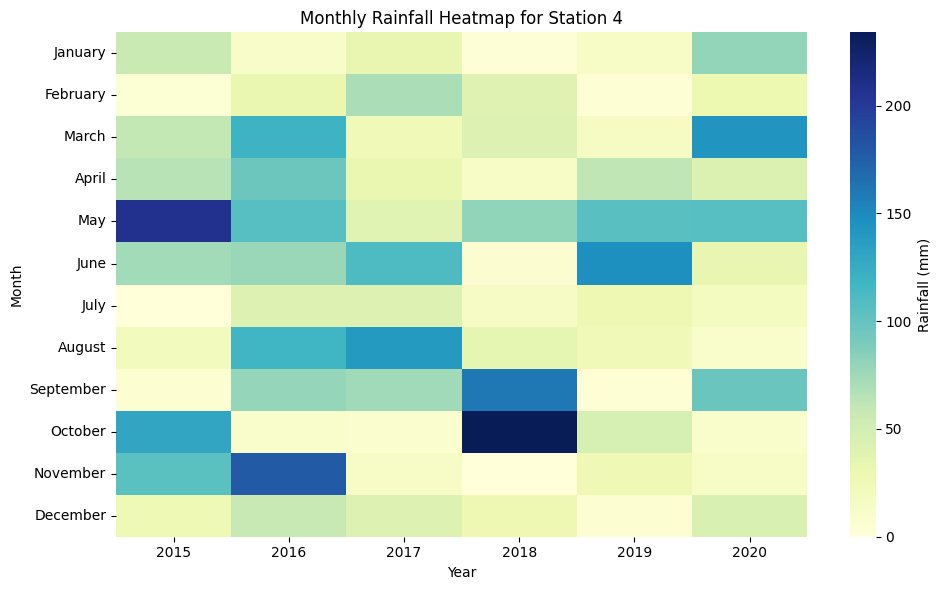

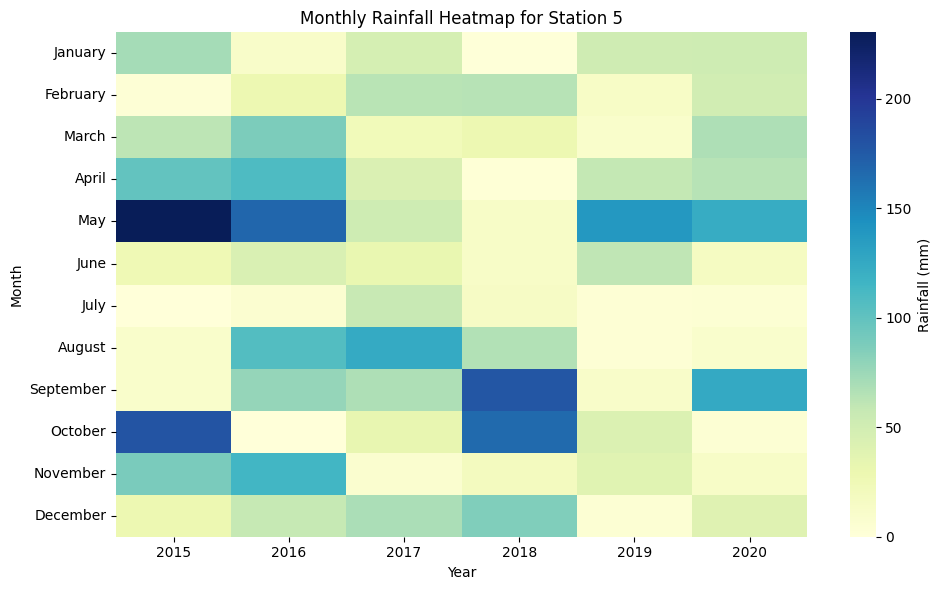

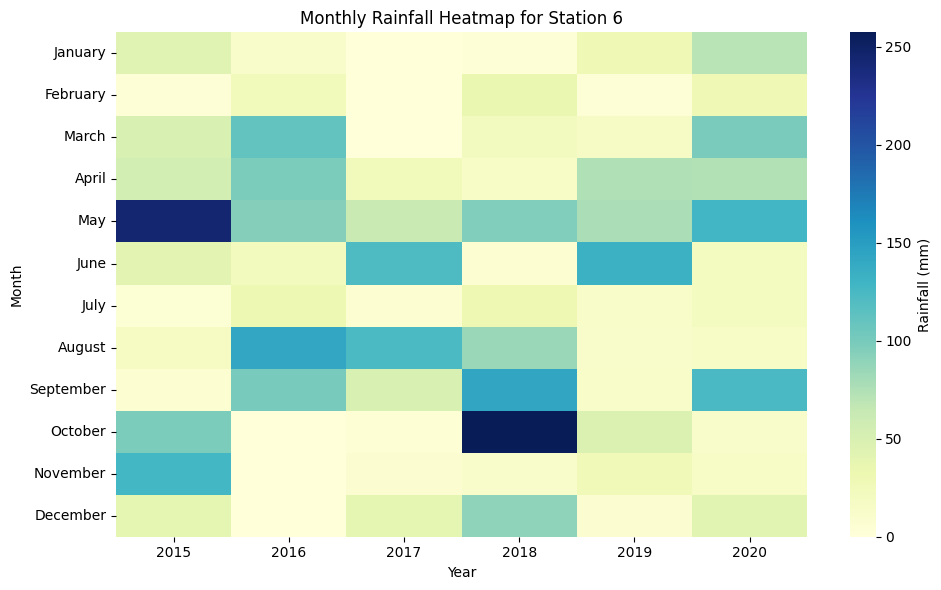

In [11]:
# Plot the heatmap for each station by month
for file, name in stations.items():
    matrix = load_rainfall_data(file, name, time = 'month_matrix')
    plt.figure(figsize = (10, 6))
    sns.heatmap(matrix, cmap = 'YlGnBu', cbar_kws = {'label': 'Rainfall (mm)'})
    plt.title(f'Monthly Rainfall Heatmap for {name}')
    plt.xlabel('Year')
    plt.ylabel('Month')
    plt.tight_layout()
    plt.show()

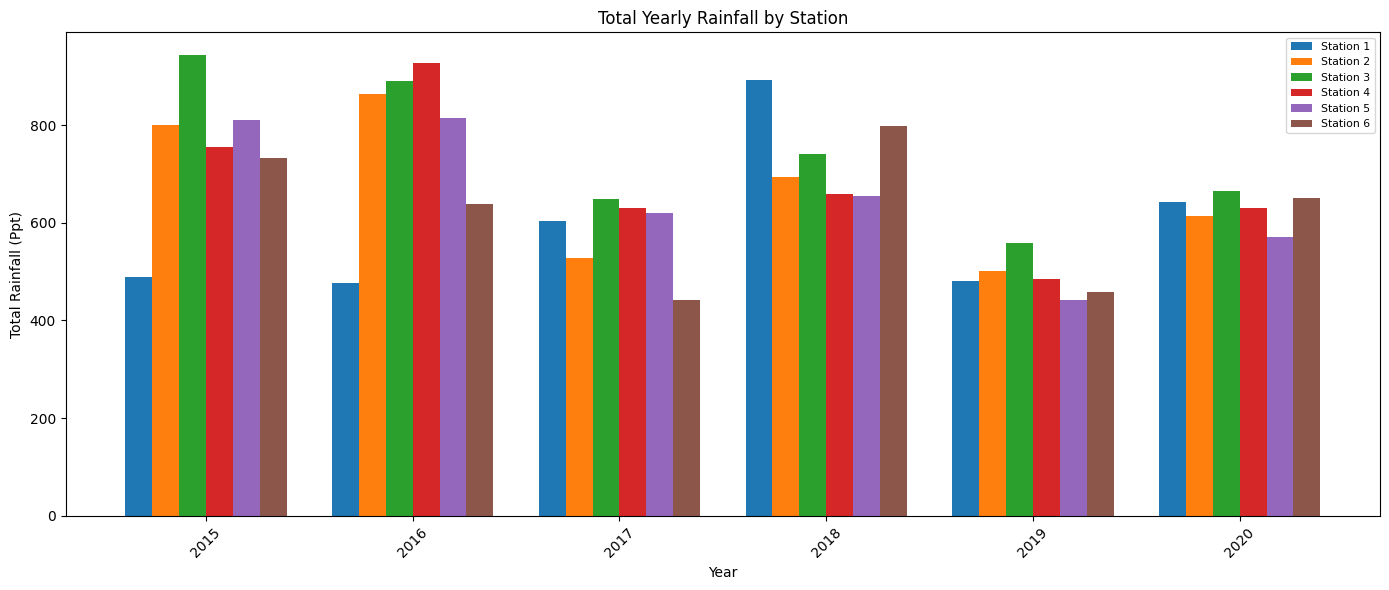

In [12]:
# Plotting variables
bar_width = 0.13
years = rain_year_df.index
x = np.arange(len(years))  # base x locations for groups

plt.figure(figsize=(14, 6))

# Loop through each station and plot its bars offset
for i, station in enumerate(rain_year_df.columns):
    plt.bar(x + i * bar_width, rain_year_df[station], width=bar_width, label=station)

# Labeling
plt.xlabel('Year')
plt.ylabel('Total Rainfall (Ppt)')
plt.title('Total Yearly Rainfall by Station')
plt.xticks(x + bar_width * 2.5, years, rotation=45)  # center ticks
plt.legend(fontsize = 7.8)
plt.tight_layout()
plt.show()

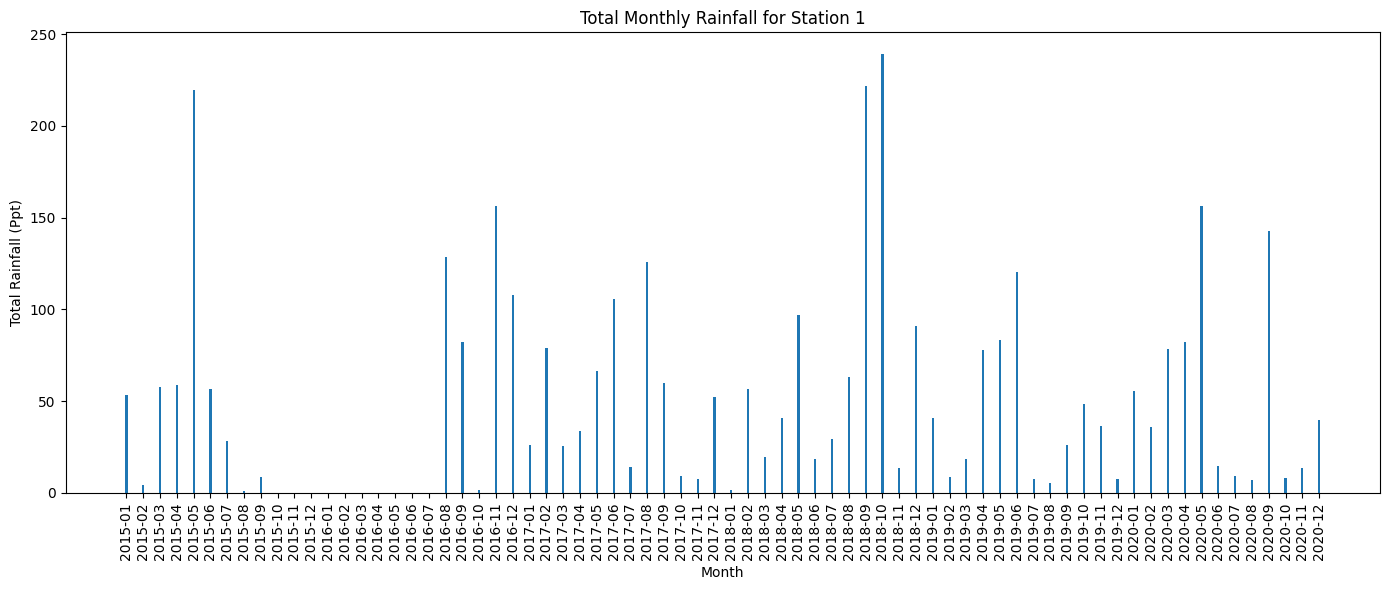

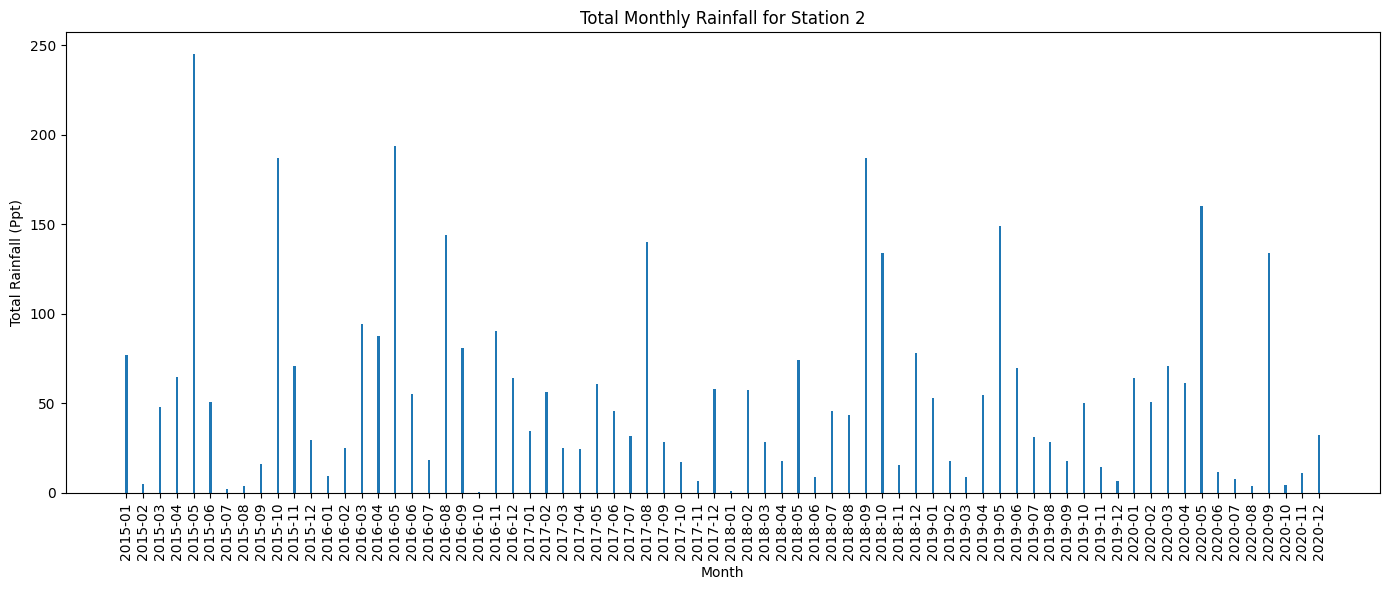

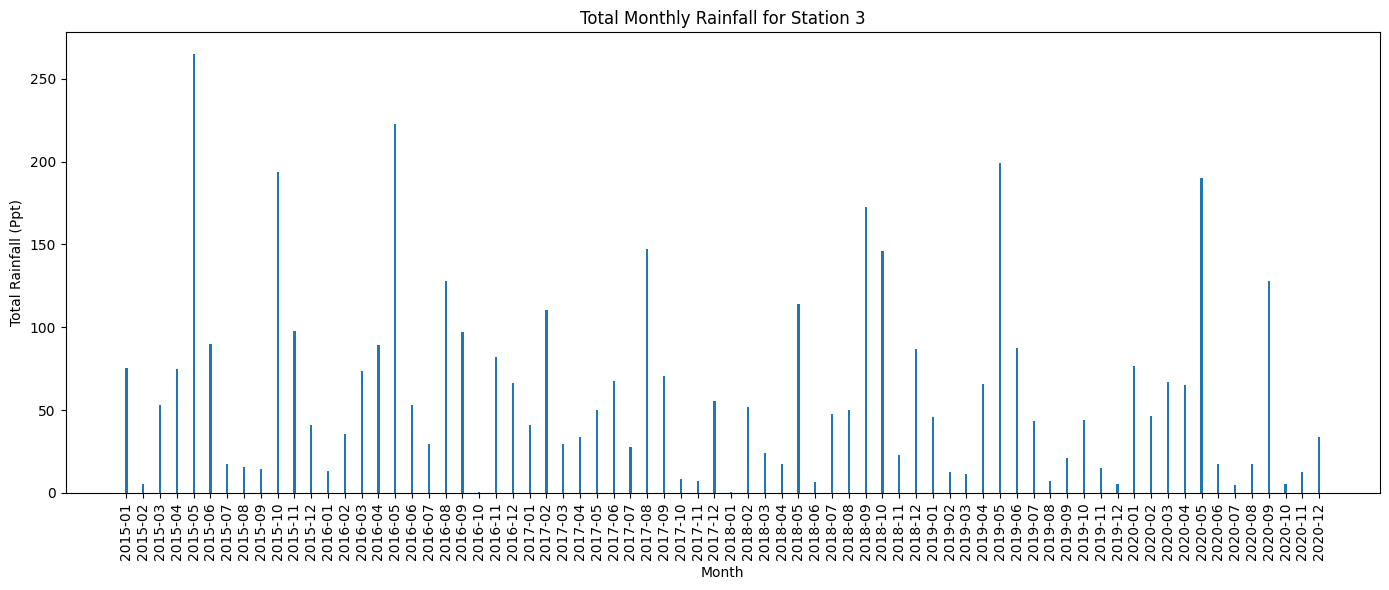

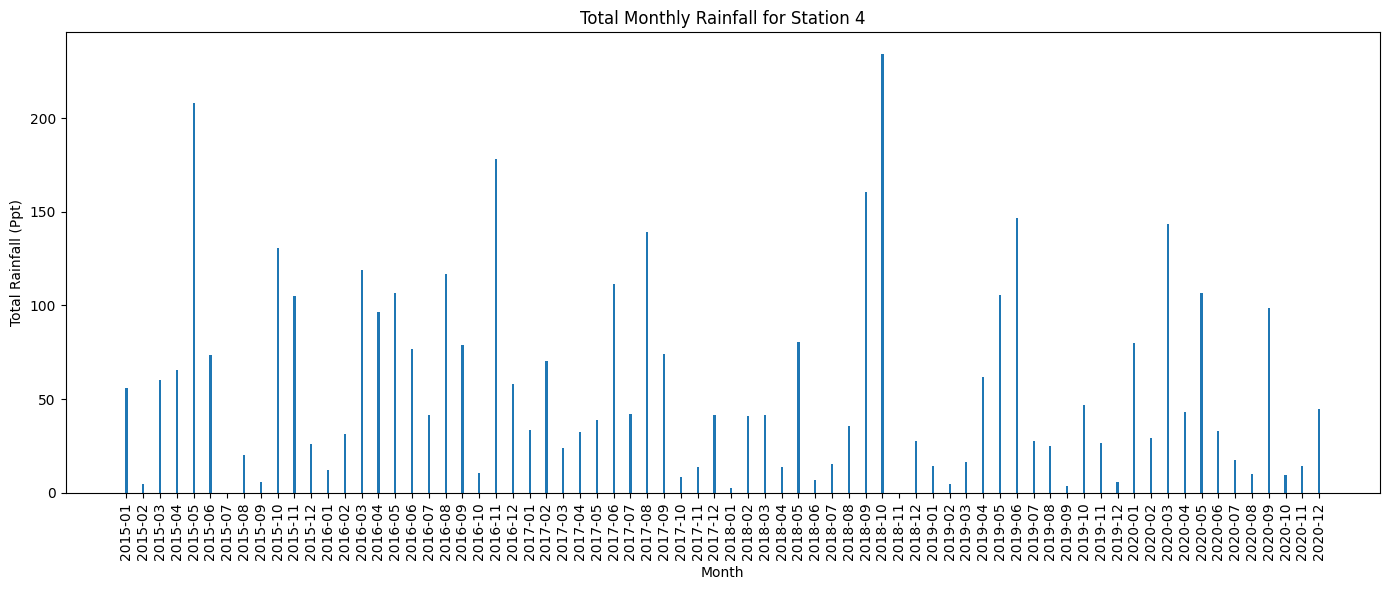

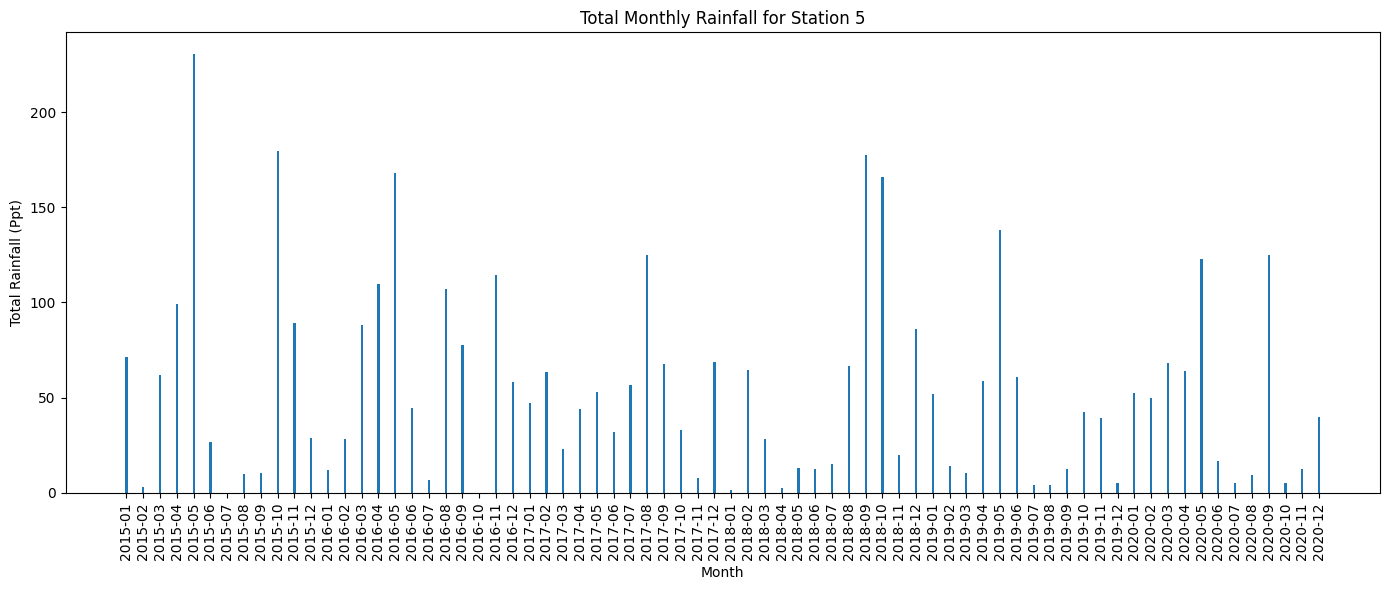

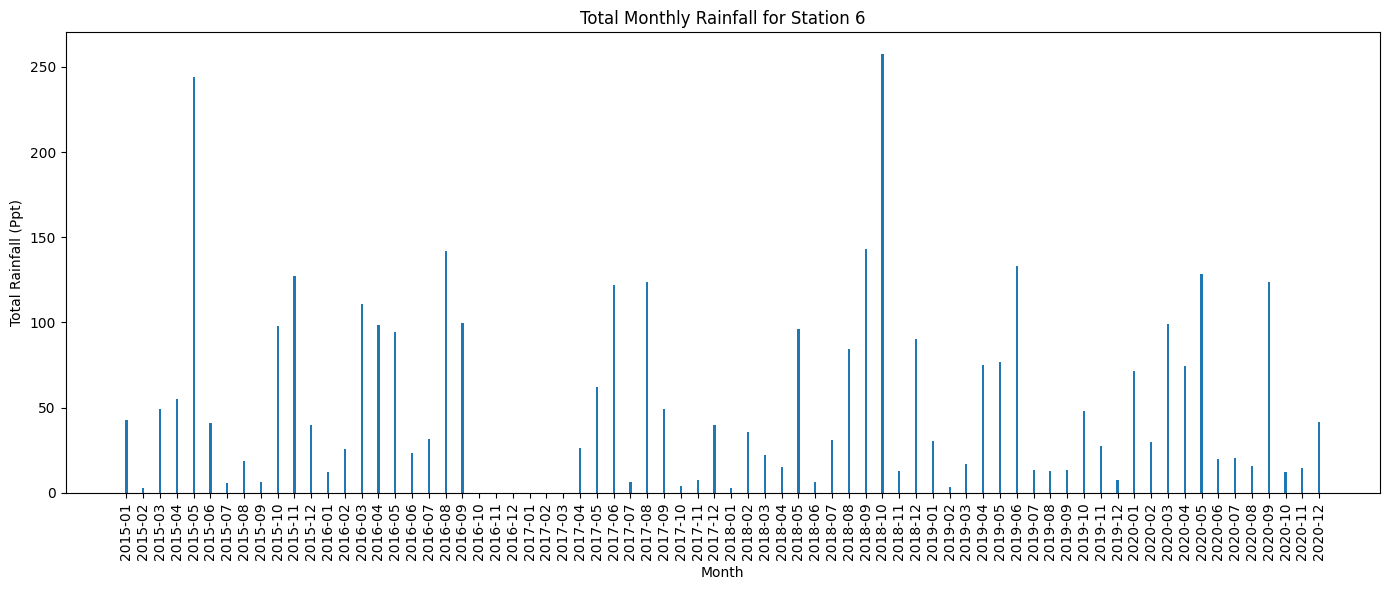

In [13]:
# Plot the heatmap by month
months = rain_month_df.index
x = np.arange(len(years))

# Loop through each station and plot its bar graph by month
for station in rain_month_df.columns:
    plt.figure(figsize=(14, 6))
    plt.bar(rain_month_df.index, rain_month_df[station], width=bar_width, label=station)
    plt.xlabel('Month')
    plt.ylabel('Total Rainfall (Ppt)')
    plt.title(f'Total Monthly Rainfall for {station}')
    plt.xticks(rotation = 90)
    plt.tight_layout()
    plt.show()

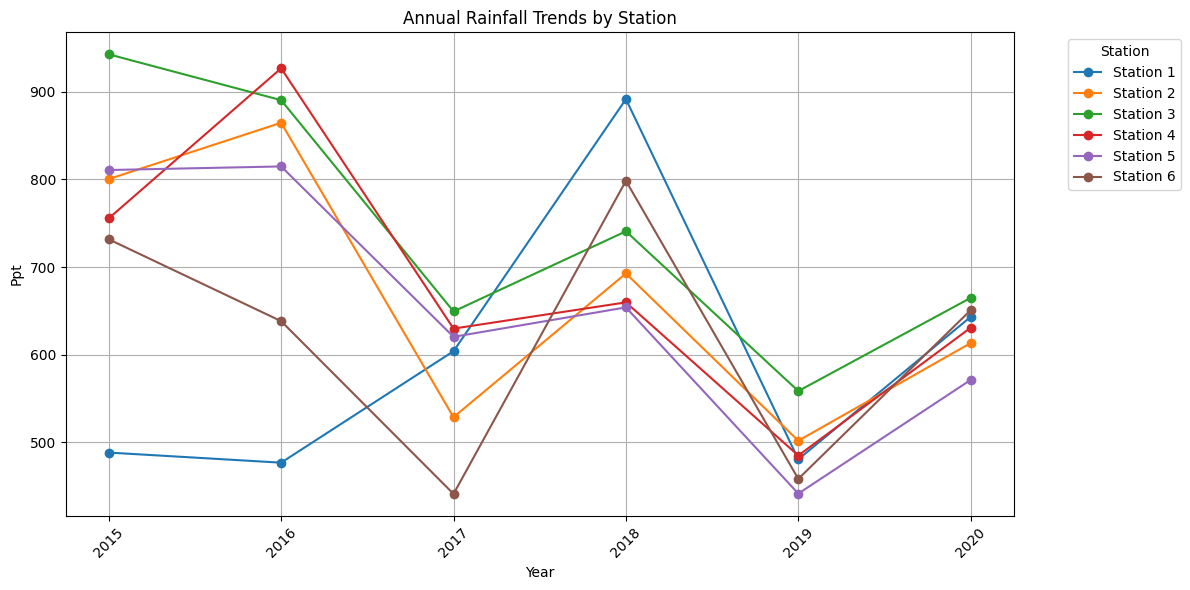

In [14]:
plt.figure(figsize=(12, 6))

for station in rain_year_df.columns:
    plt.plot(rain_year_df.index, rain_year_df[station], marker='o', linestyle='-', label=station)

plt.xlabel('Year')
plt.ylabel('Ppt')
plt.title('Annual Rainfall Trends by Station')
plt.grid(True)
plt.legend(title='Station', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

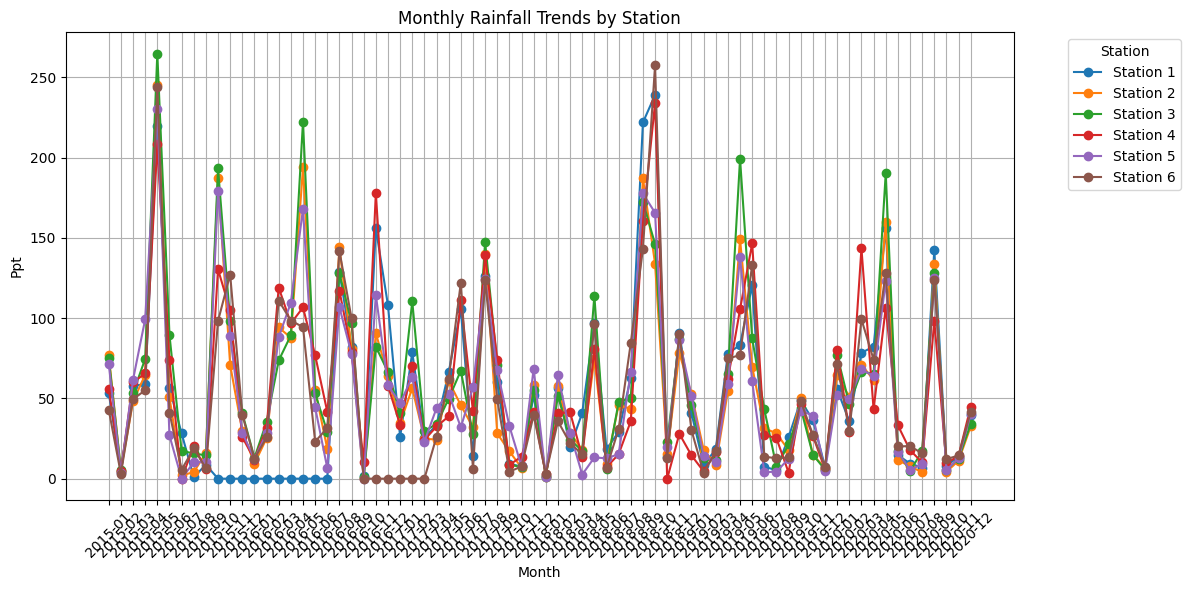

In [15]:
plt.figure(figsize=(12, 6))

for station in rain_month_df.columns:
    plt.plot(rain_month_df.index, rain_month_df[station], marker = 'o', linestyle = '-', label = station)

plt.xlabel('Month')
plt.ylabel('Ppt')
plt.title('Monthly Rainfall Trends by Station')
plt.grid(True)
plt.legend(title = 'Station', bbox_to_anchor = (1.05, 1), loc = 'upper left')
plt.xticks(rotation = 45)
plt.tight_layout()
plt.show()

<a style='text-decoration:none;line-height:16px;display:flex;color:#5B5B62;padding:10px;justify-content:end;' href='https://deepnote.com?utm_source=created-in-deepnote-cell&projectId=8e560f6b-1726-4372-a865-7294f65e8413' target="_blank">
 </img>
Created in <span style='font-weight:600;margin-left:4px;'>Deepnote</span></a>